In [1]:
import pandas as pd
# os.listdir('../../data/sefaz-sp/2026-03-05/')

In [75]:
df = pd.read_parquet('../../data/sefaz-sp/2026-03-05/df_pontos_2026-03-05_14-12.parquet')
colunas_int = ['total', 'por', 'mf', 'rc', 'ing', 'agp', 'efp','dca', 'dt', 'lte', 'cg', 'aud', 'dta', 'lta', 'cac', 'fd',]
df[colunas_int] = df[colunas_int].astype(int)
df['p1'] = df[['por', 'mf', 'rc', 'ing', 'agp', 'efp',]].sum(axis=1)
df['p2'] = df[['dca', 'dt', 'lte', 'cg', 'aud',]].sum(axis=1)
df['p3'] = df[['dta', 'lta', 'cac', 'fd',]].sum(axis=1)

df['p1_prc'] = df['p1']/(100)*100
df['p2_prc'] = df['p2']/(80)*100
df['p3_prc'] = df['p3']/(8*20)*100
df['total_prc'] = df['total']/(100+80*3)*100

df_provas = df[['posicao','usuario','p1','p2','p3','total','p1_prc','p2_prc','p3_prc','total_prc']]

In [60]:
df_provas[df_provas['usuario'] == 'cf_auditor']

,posicao,usuario,p1,p2,p3,total,p1_prc,p2_prc,p3_prc,total_prc
1022,1.023º,cf_auditor,48,57,108,213,48.0,71.25,135.0,62.647059


In [87]:
df.columns

Index(['posicao', 'usuario', 'total', 'por', 'mf', 'rc', 'ing', 'agp', 'efp',
       'dca', 'dt', 'lte', 'cg', 'aud', 'dta', 'lta', 'cac', 'fd', 'p1', 'p2',
       'p3', 'p1_prc', 'p2_prc', 'p3_prc', 'total_prc'],
      dtype='str')

In [97]:
df['mf'].iloc[0:300].mean()/15*100

np.float64(65.55555555555556)

In [86]:
def media(col,posicao):
    return df_provas[col].iloc[posicao-100:posicao].mean()
    
print('P1 100/200/300/500: {:.2f}% / {:.2f}% / {:.2f}% / {:.2f}%'.format(media('p1_prc',100),media('p1_prc',200),media('p1_prc',300),media('p1_prc',500)))
print('P2 100/200/300/500: {:.2f}% / {:.2f}% / {:.2f}% / {:.2f}%'.format(media('p2_prc',100),media('p2_prc',200),media('p2_prc',300),media('p2_prc',500)))
print('P3 100/200/300/500: {:.2f}% / {:.2f}% / {:.2f}% / {:.2f}%'.format(media('p3_prc',100),media('p3_prc',200),media('p3_prc',300),media('p3_prc',500)))

P1 100/200/300/500: 74.74% / 70.17% / 67.48% / 63.26%
P2 100/200/300/500: 85.11% / 81.62% / 80.12% / 76.29%
P3 100/200/300/500: 84.71% / 81.21% / 79.03% / 74.24%


In [62]:
df_provas[df_provas['total'] == 248]

,posicao,usuario,p1,p2,p3,total,p1_prc,p2_prc,p3_prc,total_prc
372,373º,felt,57,63,128,248,57.0,78.75,160.0,72.941176
373,374º,lfap,61,59,128,248,61.0,73.75,160.0,72.941176
374,375º,anonimo_1327,60,62,126,248,60.0,77.50,157.5,72.941176
375,376º,felhidro,58,66,124,248,58.0,82.50,155.0,72.941176
376,377º,carlost,59,65,124,248,59.0,81.25,155.0,72.941176
377,378º,cassioassis,60,64,124,248,60.0,80.00,155.0,72.941176
378,379º,moto_moto_07,63,61,124,248,63.0,76.25,155.0,72.941176
379,380º,sun_zu123,66,58,124,248,66.0,72.50,155.0,72.941176
380,381º,teimosinho,71,53,124,248,71.0,66.25,155.0,72.941176
381,382º,lucasmf_21,65,61,122,248,65.0,76.25,152.5,72.941176


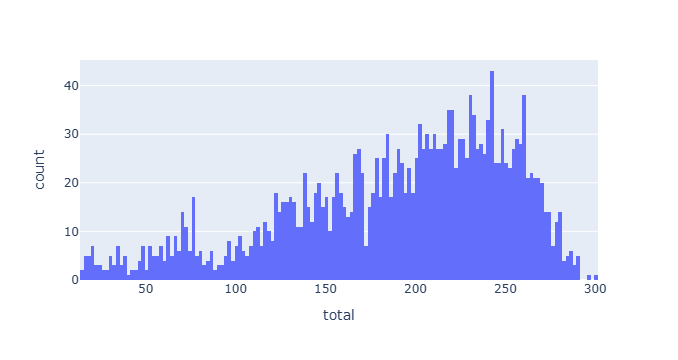

In [26]:
import plotly.express as px

# df é o seu DataFrame do Pandas com os dados do ranking
fig = px.histogram(df, x="total", nbins=10)
# Se o total é 100 e você quer 50 bins, o size é 2
fig.update_traces(xbins=dict(
    size=2  # Força cada barra a ter largura 2
))
fig.show()

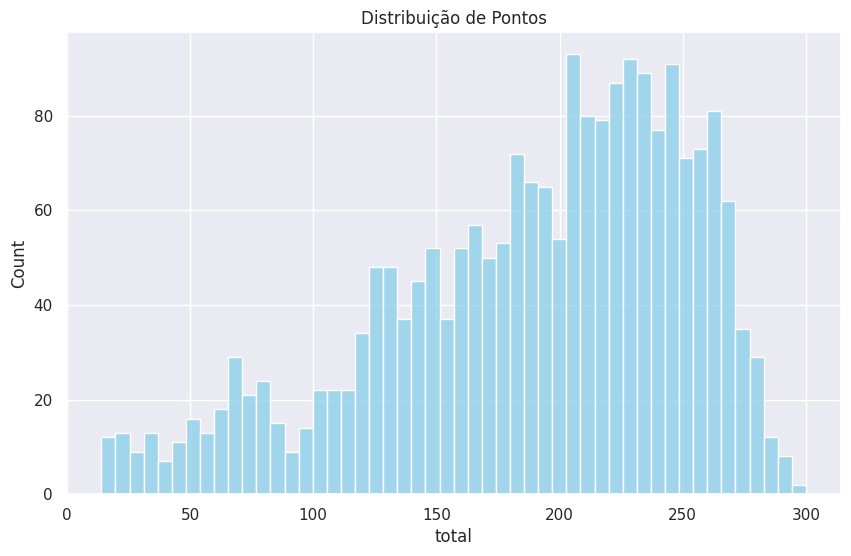

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

# Define o estilo visual
sns.set_theme(style="darkgrid")

plt.figure(figsize=(10, 6))
sns.histplot(data=df, x="total", color="skyblue", bins=50)

plt.title("Distribuição de Pontos")
plt.show()

In [9]:
import plotly.io as pio
pio.renderers.default = 'notebook_connected'